In [1]:
import pandas as pd
import numpy as np

# ML models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Clustering
from sklearn.cluster import KMeans

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics
from sklearn.metrics import accuracy_score, classification_report

# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("barbecue-bbq.csv")

df.head()

,id,recipeName,rating,totalTimeInSeconds,course,cuisine,ingredients
0,Best-Salmon-1367371,Best Salmon,4,2400.0,[Main Dishes],[Barbecue],"[salmon fillets, soy sauce, brown sugar, olive..."
1,Grilled-Bruschetta-Chicken-1372522,Grilled Bruschetta Chicken,4,2400.0,[Main Dishes],[Barbecue],"[boneless skinless chicken breast halves, sun ..."
2,Hawaiian-Beef-Teriyaki-1364621,Hawaiian Beef Teriyaki,4,2100.0,[Main Dishes],[Hawaiian],"[pineapple chunks, soy sauce, brown sugar, gar..."
3,Vietnamese-Vermicelli-Bowl-1374692,Vietnamese Vermicelli Bowl,4,3300.0,[Main Dishes],[Asian],"[chicken, lemongrass, onions, garlic cloves, k..."
4,London-Broil-1375016,London Broil,3,1500.0,[Main Dishes],[Barbecue],"[steak, soy sauce, garlic, fresh ginger, brown..."


In [3]:
print(df.info())
print(df.isnull().sum())

# Example fill (adjust based on dataset)
df = df.dropna()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  165 non-null    str    
 1   recipeName          165 non-null    str    
 2   rating              165 non-null    int64  
 3   totalTimeInSeconds  164 non-null    float64
 4   course              146 non-null    str    
 5   cuisine             165 non-null    str    
 6   ingredients         165 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 42.4 KB
None
id                     0
recipeName             0
rating                 0
totalTimeInSeconds     1
course                19
cuisine                0
ingredients            0
dtype: int64


In [5]:
print(df.columns)

Index(['id', 'recipeName', 'rating', 'totalTimeInSeconds', 'course', 'cuisine',
       'ingredients'],
      dtype='str')


In [7]:
df.head()

,id,recipeName,rating,totalTimeInSeconds,course,cuisine,ingredients
0,Best-Salmon-1367371,Best Salmon,4,2400.0,[Main Dishes],[Barbecue],"[salmon fillets, soy sauce, brown sugar, olive..."
1,Grilled-Bruschetta-Chicken-1372522,Grilled Bruschetta Chicken,4,2400.0,[Main Dishes],[Barbecue],"[boneless skinless chicken breast halves, sun ..."
2,Hawaiian-Beef-Teriyaki-1364621,Hawaiian Beef Teriyaki,4,2100.0,[Main Dishes],[Hawaiian],"[pineapple chunks, soy sauce, brown sugar, gar..."
3,Vietnamese-Vermicelli-Bowl-1374692,Vietnamese Vermicelli Bowl,4,3300.0,[Main Dishes],[Asian],"[chicken, lemongrass, onions, garlic cloves, k..."
4,London-Broil-1375016,London Broil,3,1500.0,[Main Dishes],[Barbecue],"[steak, soy sauce, garlic, fresh ginger, brown..."


In [8]:
for col in df.columns:
    print(col)

id
recipeName
rating
totalTimeInSeconds
course
cuisine
ingredients


In [10]:
print(dir())

['ExtraTreesClassifier', 'In', 'KMeans', 'Out', 'PCA', 'RandomForestClassifier', 'TfidfVectorizer', '_', '_2', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'accuracy_score', 'classification_report', 'col', 'df', 'exit', 'get_ipython', 'np', 'open', 'pd', 'plt', 'quit', 'text_column', 'tfidf', 'train_test_split']


In [14]:
print(df.head())
print(df.columns)

                                   id  ...                                        ingredients
0                 Best-Salmon-1367371  ...  [salmon fillets, soy sauce, brown sugar, olive...
1  Grilled-Bruschetta-Chicken-1372522  ...  [boneless skinless chicken breast halves, sun ...
2      Hawaiian-Beef-Teriyaki-1364621  ...  [pineapple chunks, soy sauce, brown sugar, gar...
3  Vietnamese-Vermicelli-Bowl-1374692  ...  [chicken, lemongrass, onions, garlic cloves, k...
4                London-Broil-1375016  ...  [steak, soy sauce, garlic, fresh ginger, brown...

[5 rows x 7 columns]
Index(['id', 'recipeName', 'rating', 'totalTimeInSeconds', 'course', 'cuisine',
       'ingredients'],
      dtype='str')


In [17]:
df.head()

,id,recipeName,rating,totalTimeInSeconds,course,cuisine,ingredients
0,Best-Salmon-1367371,Best Salmon,4,2400.0,[Main Dishes],[Barbecue],"[salmon fillets, soy sauce, brown sugar, olive..."
1,Grilled-Bruschetta-Chicken-1372522,Grilled Bruschetta Chicken,4,2400.0,[Main Dishes],[Barbecue],"[boneless skinless chicken breast halves, sun ..."
2,Hawaiian-Beef-Teriyaki-1364621,Hawaiian Beef Teriyaki,4,2100.0,[Main Dishes],[Hawaiian],"[pineapple chunks, soy sauce, brown sugar, gar..."
3,Vietnamese-Vermicelli-Bowl-1374692,Vietnamese Vermicelli Bowl,4,3300.0,[Main Dishes],[Asian],"[chicken, lemongrass, onions, garlic cloves, k..."
4,London-Broil-1375016,London Broil,3,1500.0,[Main Dishes],[Barbecue],"[steak, soy sauce, garlic, fresh ginger, brown..."


In [24]:
for col in df.columns:
    print(col)

id
recipeName
rating
totalTimeInSeconds
course
cuisine
ingredients


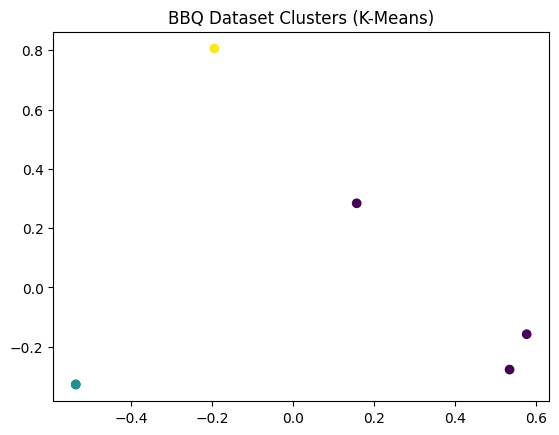

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Example dataset (replace with your real data)
text_data = [
    "The BBQ ribs were amazing",
    "Terrible service and cold food",
    "Loved the smoky chicken",
    "Food was bland and overpriced",
    "Best barbecue I've ever had",
    "Wait time was too long"
]

# 1. Vectorize text
vectorizer = TfidfVectorizer()
X_text = vectorizer.fit_transform(text_data)

# 2. Cluster
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_text)

# 3. Reduce dimensions
pca = PCA(n_components=2)
reduced = pca.fit_transform(X_text.toarray())

# 4. Plot
plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, cmap="viridis")
plt.title("BBQ Dataset Clusters (K-Means)")
plt.show()

In [30]:
print(df.columns)

Index(['id', 'recipeName', 'rating', 'totalTimeInSeconds', 'course', 'cuisine',
       'ingredients'],
      dtype='str')
